In [31]:
# Install all required libraries (run once)
!pip install -q numpy pandas matplotlib seaborn scikit-learn tensorflow xgboost scipy



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **DeepCSAT: E-Commerce Customer Satisfaction Score Prediction**

##### **Project Type**    - Classification, NLP, Deep Learning
##### **Contribution**    - Individual / Team (update as applicable)
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**


# **Project Summary**

Customer satisfaction (CSAT) is a critical metric for e-commerce platforms, especially within customer support operations. Every interaction between a customer and a support agent (through chat, call, email, etc.) can positively or negatively influence the final CSAT score. Being able to predict CSAT in advance, based on interaction and operational features, can help organizations monitor service quality in real time and intervene proactively.

In this project, we build an end-to-end machine learning and deep learning pipeline to predict the **CSAT Score (1–5)** from historical customer support interaction data. The dataset includes detailed information such as channel, category and sub-category of the issue, timestamps (order time, issue reported time, issue responded time, and survey response time), customer city, product details, monetary information like item price, operational metrics such as connected handling time, and agent hierarchy information (agent, supervisor, manager, tenure bucket, shift). We also use the textual **Customer Remarks** field, which captures the customer’s qualitative feedback.

The project starts with extensive **Exploratory Data Analysis (EDA)** to understand the distribution of CSAT scores and the relationship between CSAT and key features like interaction category, channels, and handling time. We then perform **data cleaning and preprocessing**, including handling missing values, converting date/time fields to proper datetime formats, and engineering new time-based features such as response time, survey delay, and order-to-issue time. We further extract components like hour, day, weekday, and month from timestamps to capture temporal patterns in customer satisfaction.

For the **NLP part**, we preprocess the `Customer Remarks` text by lowercasing, removing punctuation, removing stopwords, and normalizing white spaces. We then convert the cleaned remarks into numerical features using **TF‑IDF vectorization**, which captures the importance of words across all interactions without exploding dimensionality. Categorical variables (e.g., channel, category, agent shift) are encoded using **One‑Hot Encoding**, while numeric variables (e.g., item price, handling time, engineered time differences) are scaled using **StandardScaler** to stabilize learning for gradient-based models.

We formulate CSAT prediction as a **multi-class classification problem with five classes (1–5)**. Our main model is an **Artificial Neural Network (ANN)** implemented using TensorFlow/Keras, with a dense architecture: 128‑unit and 64‑unit hidden layers with ReLU activation, dropout for regularization, followed by a 32‑unit layer and a 5‑unit softmax output layer. The model is trained with the **Adam optimizer**, **categorical cross-entropy loss**, mini-batch training, and **early stopping** based on validation loss to avoid overfitting. In addition to the ANN, we implement **Random Forest** and **XGBoost** classifiers as baseline and benchmark models for comparison.

Model performance is evaluated using **accuracy, precision, recall, F1-score, and confusion matrix** on a held-out test set (20% of the data). We also visualize training vs. validation accuracy to assess convergence and generalization. From the final models, we derive **business insights**, such as which channels, categories, or handling time ranges are associated with lower satisfaction, how response time affects CSAT, and which communication channels tend to yield higher satisfaction. Finally, we save the trained ANN model as `csat_model.h5` for potential deployment in a real-time CSAT monitoring system.

Overall, this project demonstrates a complete, deployment-ready workflow that combines structured data, temporal features, and unstructured text to predict customer satisfaction in an e-commerce support context, and provides actionable recommendations for improving service quality.


# **GitHub Link**

Provide your GitHub repository link here once you upload the notebook and related files.


# **Problem Statement**

The objective of this project is to develop a predictive model that can estimate the **Customer Satisfaction Score (CSAT)** on a scale of **1 to 5** for e-commerce customer support interactions. Each interaction is characterized by multiple attributes, including support channel, interaction category and sub-category, timestamps (order time, issue reported time, issue responded time, and survey response time), customer demographics (e.g., city), product information (e.g., product category, item price), operational metrics (e.g., connected handling time), and agent-related features (e.g., agent name, supervisor, manager, tenure bucket, shift). The dataset also includes free-text **Customer Remarks** summarizing the customer’s perception of the interaction.

The goal is to build an end-to-end machine learning and deep learning pipeline that:
1. Cleans and preprocesses the dataset, including handling missing values and converting date/time fields.
2. Engineers meaningful features such as response time, survey delay, and order-to-issue time, as well as temporal features (hour, day, weekday, month).
3. Processes the textual Customer Remarks using NLP techniques and converts them into numerical representations.
4. Encodes categorical variables and scales numerical variables appropriately.
5. Trains and evaluates an **Artificial Neural Network (ANN)** to predict CSAT scores as a multi-class classification problem.
6. Optionally builds additional baseline models (Random Forest and XGBoost) for comparison.
7. Evaluates all models using appropriate classification metrics and visualizations.
8. Generates insights that help e-commerce businesses understand which factors most influence customer satisfaction and how to improve customer support operations.

The final deliverable is a Jupyter Notebook that follows academic guidelines, includes detailed EDA, clearly documented preprocessing steps, model development, evaluation, visualization, and business interpretation, and saves the best-performing ANN model as `csat_model.h5`.


In [32]:
# Import core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
from datetime import datetime

# Preprocessing & feature engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Classical ML models (bonus comparison)
from sklearn.ensemble import RandomForestClassifier

# XGBoost (bonus – may need: pip install xgboost)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False
    print("xgboost is not installed. Install it with `pip install xgboost` to run the XGBoost model.")

# Deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Text preprocessing helpers
import re
import string

# Display options
pd.set_option('display.max_columns', 100)
sns.set(style="whitegrid")


In [33]:
# Load the e-commerce customer support dataset
data_path = "eCommerce_Customer_support_data.csv"  # ensure the file is in the same folder as the notebook

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (85907, 20)


In [34]:
# First few rows
df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


Number of rows: 85907
Number of columns: 20

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handlin

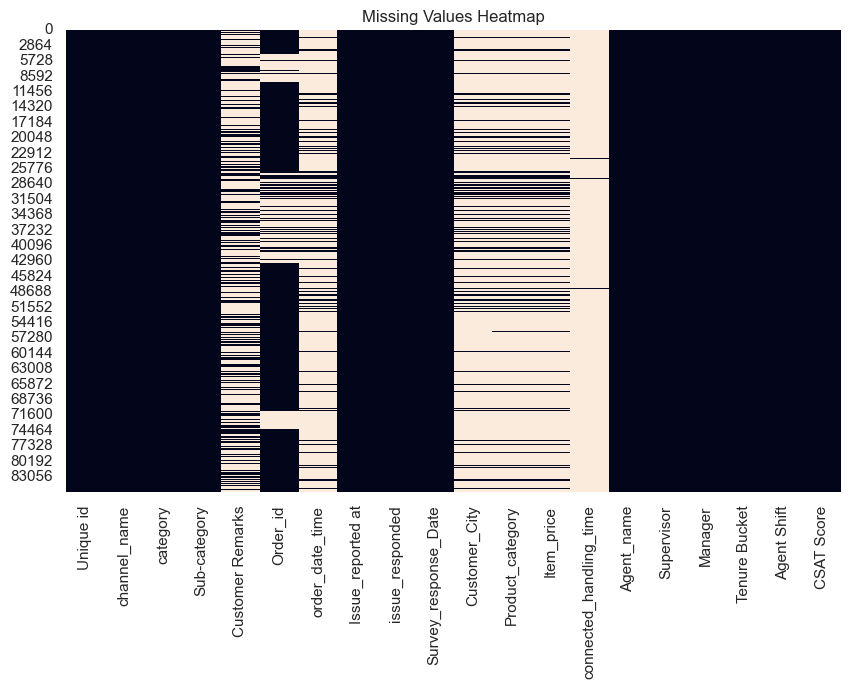

In [35]:
# Rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Dataset info
print("\nDataset Info:")
df.info()

# Duplicate values
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Visualizing missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


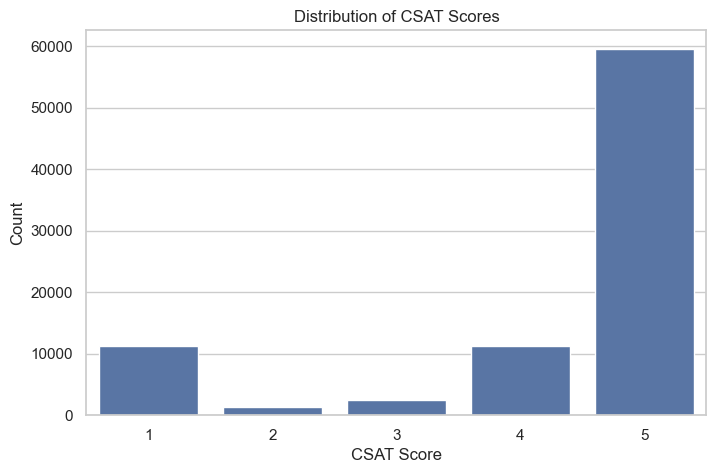

CSAT Score
1    0.130723
2    0.014935
3    0.029776
4    0.130595
5    0.693971
Name: proportion, dtype: float64


In [36]:
# CSAT score distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CSAT Score', order=sorted(df['CSAT Score'].dropna().unique()))
plt.title("Distribution of CSAT Scores")
plt.xlabel("CSAT Score")
plt.ylabel("Count")
plt.show()

print(df['CSAT Score'].value_counts(normalize=True).sort_index())


In [37]:
# Convert relevant date/time columns to datetime
# Use the actual column names present in the dataset
date_cols = [
    'order_date_time',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

existing_date_cols = [c for c in date_cols if c in df.columns]
print(df[existing_date_cols].dtypes)


C:\Users\afk9p\AppData\Local\Temp\ipykernel_6936\3830642197.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce')


order_date_time         datetime64[ns]
Issue_reported at       datetime64[ns]
issue_responded         datetime64[ns]
Survey_response_Date    datetime64[ns]
dtype: object


C:\Users\afk9p\AppData\Local\Temp\ipykernel_6936\3830642197.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [38]:
# Create time-based features (in hours)
if {'issue_responded', 'Issue_reported at'}.issubset(df.columns):
    df['response_time_hours'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 3600.0
else:
    df['response_time_hours'] = np.nan

if {'Survey_response_Date', 'issue_responded'}.issubset(df.columns):
    df['survey_delay_hours'] = (df['Survey_response_Date'] - df['issue_responded']).dt.total_seconds() / 3600.0
else:
    df['survey_delay_hours'] = np.nan

if {'Issue_reported at', 'order_date_time'}.issubset(df.columns):
    df['order_to_issue_hours'] = (df['Issue_reported at'] - df['order_date_time']).dt.total_seconds() / 3600.0
else:
    df['order_to_issue_hours'] = np.nan

# Simple sanity check
df[['response_time_hours', 'survey_delay_hours', 'order_to_issue_hours']].describe()


,response_time_hours,survey_delay_hours,order_to_issue_hours
count,31633.000000,31885.000000,7855.000000
mean,77.452537,823.673371,545.350552
std,285.219791,2405.165161,2657.485743
min,0.000000,-2855.983333,-4919.433333
25%,0.033333,-1427.350000,-1299.225000
50%,0.100000,703.133333,1511.900000
75%,0.683333,2818.350000,2312.658333
max,2951.616667,4920.000000,15865.350000


In [39]:
# Extract hour, day, weekday, month from key timestamps
def add_datetime_parts(df, col_prefix, col):
    df[f'{col_prefix}_hour'] = df[col].dt.hour
    df[f'{col_prefix}_day'] = df[col].dt.day
    df[f'{col_prefix}_weekday'] = df[col].dt.weekday
    df[f'{col_prefix}_month'] = df[col].dt.month

if 'order_date_time' in df.columns:
    add_datetime_parts(df, 'order', 'order_date_time')

if 'Issue_reported at' in df.columns:
    add_datetime_parts(df, 'issue_reported', 'Issue_reported at')

if 'issue_responded' in df.columns:
    add_datetime_parts(df, 'issue_responded', 'issue_responded')

df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_hours,survey_delay_hours,order_to_issue_hours,order_hour,order_day,order_weekday,order_month,issue_reported_hour,issue_reported_day,issue_reported_weekday,issue_reported_month,issue_responded_hour,issue_responded_day,issue_responded_weekday,issue_responded_month
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0.566667,4908.216667,NaN,NaN,NaN,NaN,NaN,11.0,8.0,6.0,1.0,11.0,8.0,6.0,1.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0.033333,4907.100000,NaN,NaN,NaN,NaN,NaN,12.0,8.0,6.0,1.0,12.0,8.0,6.0,1.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0.366667,4899.366667,NaN,NaN,NaN,NaN,NaN,20.0,8.0,6.0,1.0,20.0,8.0,6.0,1.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0.333333,4898.733333,NaN,NaN,NaN,NaN,NaN,20.0,8.0,6.0,1.0,21.0,8.0,6.0,1.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0.033333,4909.466667,NaN,NaN,NaN,NaN,NaN,10.0,8.0,6.0,1.0,10.0,8.0,6.0,1.0


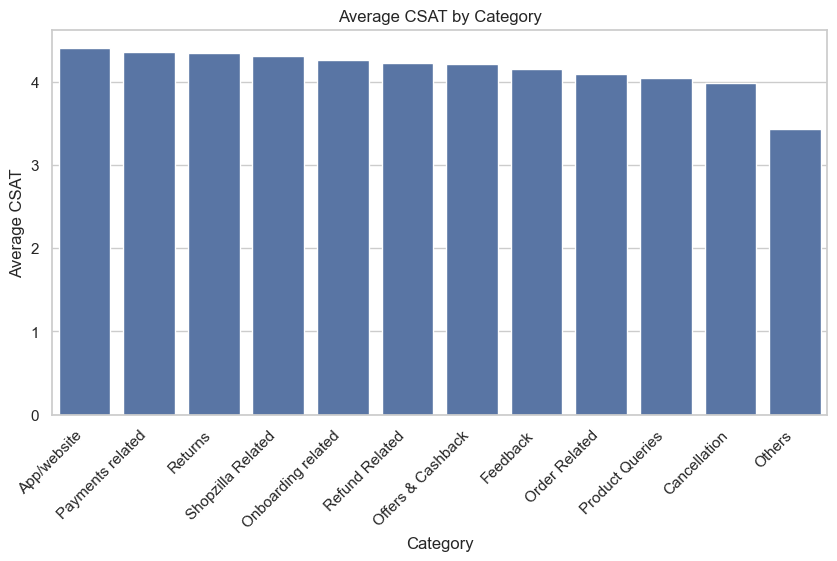

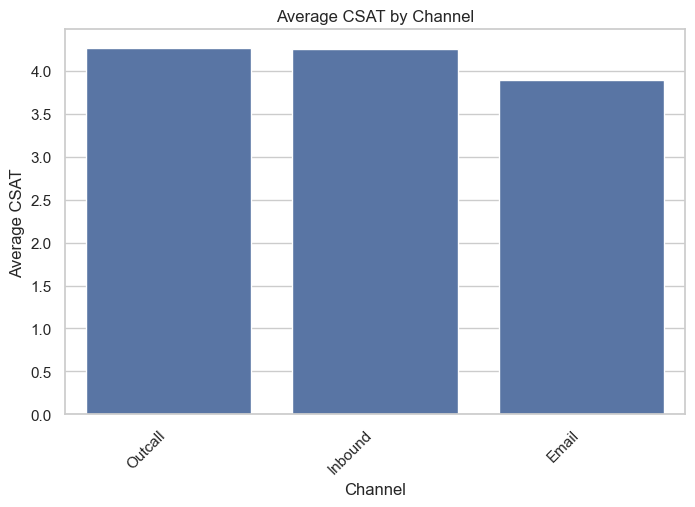

In [40]:
# Average CSAT by Category
if 'category' in df.columns:
    plt.figure(figsize=(10, 5))
    cat_csat = df.groupby('category')['CSAT Score'].mean().sort_values(ascending=False)
    sns.barplot(x=cat_csat.index, y=cat_csat.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Average CSAT by Category")
    plt.ylabel("Average CSAT")
    plt.xlabel("Category")
    plt.show()

# Average CSAT by Channel
if 'channel_name' in df.columns:
    plt.figure(figsize=(8, 5))
    ch_csat = df.groupby('channel_name')['CSAT Score'].mean().sort_values(ascending=False)
    sns.barplot(x=ch_csat.index, y=ch_csat.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Average CSAT by Channel")
    plt.ylabel("Average CSAT")
    plt.xlabel("Channel")
    plt.show()


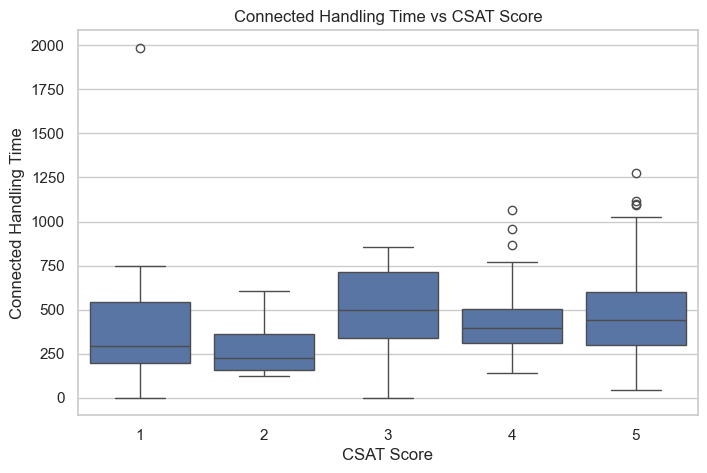

In [41]:
# Relationship between connected handling time and CSAT
if 'connected_handling_time' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='CSAT Score', y='connected_handling_time')
    plt.title("Connected Handling Time vs CSAT Score")
    plt.xlabel("CSAT Score")
    plt.ylabel("Connected Handling Time")
    plt.show()


In [42]:
# Text preprocessing for Customer Remarks
def clean_text(text):
    if pd.isnull(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\\S+|www\\.\\S+', '', text)
    # Remove digits
    text = re.sub(r'\\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

text_col = 'Customer Remarks'
if text_col in df.columns:
    df[text_col + '_clean'] = df[text_col].astype(str).apply(clean_text)
else:
    raise ValueError("Customer Remarks column not found in dataset.")

df[[text_col, text_col + '_clean']].head()


,Customer Remarks,Customer Remarks_clean
0,NaN,nan
1,NaN,nan
2,NaN,nan
3,NaN,nan
4,NaN,nan


In [43]:
# Simple missing value handling strategy
target_col = 'CSAT Score'

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if text_col in categorical_cols:
    categorical_cols.remove(text_col)

# Fill numeric with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Engineered numeric features
engineered_numeric = ['response_time_hours', 'survey_delay_hours', 'order_to_issue_hours']
for col in engineered_numeric:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                       0
order_date_time            68693
Issue_reported at          53933
issue_responded            54022
Survey_response_Date           0
Customer_City                  0
Product_category               0
Item_price                     0
connected_handling_time        0
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
response_time_hours            0
survey_delay_hours             0
order_to_issue_hours           0
order_hour                     0
order_day                      0
order_weekday                  0
order_month                    0
issue_reported_hour            0
issue_reported_day             0
issue_repo

In [44]:
# Define feature columns

numeric_features = []
for col in [
    'Item_price',
    'connected_handling_time',
    'response_time_hours',
    'survey_delay_hours',
    'order_to_issue_hours',
    'order_hour', 'order_day', 'order_weekday', 'order_month',
    'issue_reported_hour', 'issue_reported_day', 'issue_reported_weekday', 'issue_reported_month',
    'issue_responded_hour', 'issue_responded_day', 'issue_responded_weekday', 'issue_responded_month'
]:
    if col in df.columns:
        numeric_features.append(col)

categorical_features = []
for col in [
    'channel_name',
    'category',
    'Sub-category',
    'Customer_City',
    'Product_category',
    'Agent_name',
    'Supervisor',
    'Manager',
    'Tenure Bucket',
    'Agent Shift'
]:
    if col in df.columns:
        categorical_features.append(col)

text_feature = text_col + '_clean'

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Text feature:", text_feature)

y = df[target_col].values
print("Unique CSAT scores:", np.unique(y))


Numeric features: ['Item_price', 'connected_handling_time', 'response_time_hours', 'survey_delay_hours', 'order_to_issue_hours', 'order_hour', 'order_day', 'order_weekday', 'order_month', 'issue_reported_hour', 'issue_reported_day', 'issue_reported_weekday', 'issue_reported_month', 'issue_responded_hour', 'issue_responded_day', 'issue_responded_weekday', 'issue_responded_month']
Categorical features: ['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
Text feature: Customer Remarks_clean
Unique CSAT scores: [1 2 3 4 5]


In [45]:
# Split data into train and test sets
feature_cols = numeric_features + categorical_features + [text_feature]
X = df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (68725, 28)
Test shape: (17182, 28)


In [46]:
# ColumnTransformer for numeric, categorical, and text features

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

text_transformer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2)
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('txt', text_transformer, text_feature)
    ]
)

# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessed train shape:", X_train_processed.shape)
print("Preprocessed test shape:", X_test_processed.shape)


Preprocessed train shape: (68725, 6146)
Preprocessed test shape: (17182, 6146)


In [47]:
from scipy import sparse

# Ensure dense arrays for Keras
if sparse.issparse(X_train_processed):
    X_train_ann = X_train_processed.toarray()
    X_test_ann = X_test_processed.toarray()
else:
    X_train_ann = X_train_processed
    X_test_ann = X_test_processed

# Convert target to 0–4 indices (for CSAT 1–5)
y_train_indices = y_train - 1
y_test_indices = y_test - 1

num_classes = len(np.unique(y))
print("Number of classes:", num_classes)

# One-hot encode targets for ANN
y_train_cat = to_categorical(y_train_indices, num_classes=num_classes)
y_test_cat = to_categorical(y_test_indices, num_classes=num_classes)

X_train_ann.shape, y_train_cat.shape


Number of classes: 5


((68725, 6146), (68725, 5))

In [48]:
from tensorflow.keras.layers import Input

input_dim = X_train_ann.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       786,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,317 (3.04 MB)

 Trainable params: 797,317 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_ann,
    y_train_cat,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7123 - loss: 0.8916 - val_accuracy: 0.7198 - val_loss: 0.8625
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7271 - loss: 0.8340 - val_accuracy: 0.7181 - val_loss: 0.8674
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7344 - loss: 0.8065 - val_accuracy: 0.7208 - val_loss: 0.8712
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7408 - loss: 0.7756 - val_accuracy: 0.7187 - val_loss: 0.8916


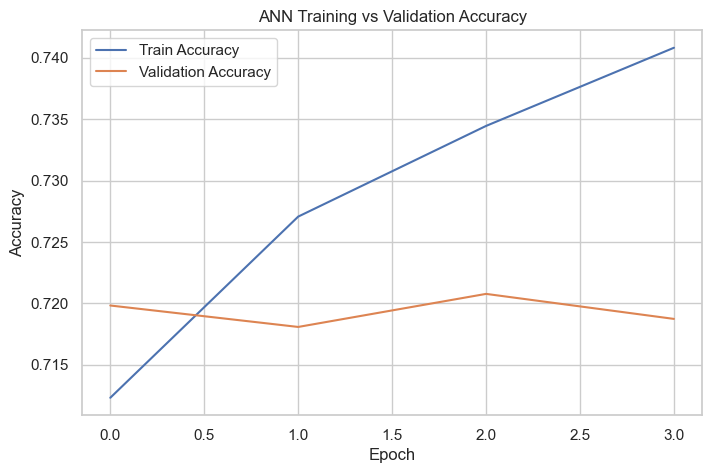

In [50]:
# Plot training & validation accuracy values
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
ANN Test Accuracy: 0.7225002910022116
ANN Precision (weighted): 0.5883703371203212
ANN Recall (weighted): 0.7225002910022116
ANN F1-score (weighted): 0.6371466721253682

Classification Report (ANN):
              precision    recall  f1-score   support

           1      0.627     0.336     0.437      2246
           2      0.000     0.000     0.000       256
           3      0.000     0.000     0.000       512
           4      0.000     0.000     0.000      2244
           5      0.730     0.978     0.836     11924

    accuracy                          0.723     17182
   macro avg      0.271     0.263     0.255     17182
weighted avg      0.588     0.723     0.637     17182



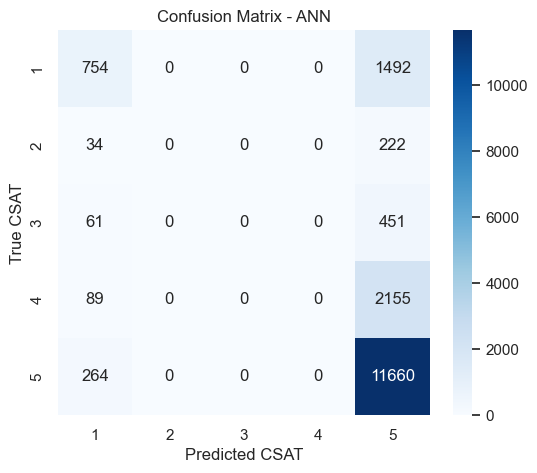

In [51]:
# Predict probabilities and classes
y_pred_proba_ann = model.predict(X_test_ann)
y_pred_ann_indices = np.argmax(y_pred_proba_ann, axis=1)
y_pred_ann = y_pred_ann_indices + 1  # convert back to 1–5 CSAT

# Metrics
ann_accuracy = accuracy_score(y_test, y_pred_ann)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_ann, average='weighted', zero_division=0
)

print("ANN Test Accuracy:", ann_accuracy)
print("ANN Precision (weighted):", precision)
print("ANN Recall (weighted):", recall)
print("ANN F1-score (weighted):", f1)

print("\nClassification Report (ANN):")
print(classification_report(y_test, y_pred_ann, digits=3, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_test)),
            yticklabels=sorted(np.unique(y_test)))
plt.xlabel('Predicted CSAT')
plt.ylabel('True CSAT')
plt.title('Confusion Matrix - ANN')
plt.show()


In [52]:
# Random Forest classifier on the same preprocessed features
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_processed, y_train)
y_pred_rf = rf_clf.predict(X_test_processed)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average='weighted', zero_division=0
)

print("Random Forest Test Accuracy:", rf_acc)
print("Random Forest Precision (weighted):", rf_prec)
print("Random Forest Recall (weighted):", rf_rec)
print("Random Forest F1-score (weighted):", rf_f1)


Random Forest Test Accuracy: 0.697124898149226
Random Forest Precision (weighted): 0.6036196953295253
Random Forest Recall (weighted): 0.697124898149226
Random Forest F1-score (weighted): 0.6202816498346497


In [53]:
if xgb_available:
    # XGBoost expects class labels starting at 0. Convert CSAT 1–5 -> 0–4
    y_train_xgb = y_train - 1
    y_test_xgb = y_test - 1

    xgb_clf = XGBClassifier(
        objective='multi:softmax',
        num_class=num_classes,
        eval_metric='mlogloss',
        learning_rate=0.1,
        max_depth=6,
        n_estimators=200,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    xgb_clf.fit(X_train_processed, y_train_xgb)
    y_pred_xgb = xgb_clf.predict(X_test_processed)

    xgb_acc = accuracy_score(y_test_xgb, y_pred_xgb)
    xgb_prec, xgb_rec, xgb_f1, _ = precision_recall_fscore_support(
        y_test_xgb, y_pred_xgb, average='weighted', zero_division=0
    )

    print("XGBoost Test Accuracy:", xgb_acc)
    print("XGBoost Precision (weighted):", xgb_prec)
    print("XGBoost Recall (weighted):", xgb_rec)
    print("XGBoost F1-score (weighted):", xgb_f1)
else:
    print("Skipping XGBoost model because xgboost is not installed.")


XGBoost Test Accuracy: 0.7193574671167501
XGBoost Precision (weighted): 0.623347785298947
XGBoost Recall (weighted): 0.7193574671167501
XGBoost F1-score (weighted): 0.6283504893397345


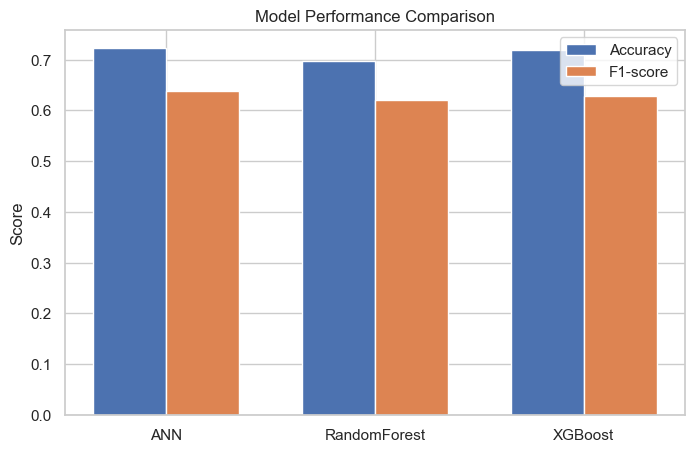

In [54]:
# Compare models based on accuracy and F1-score
model_names = ['ANN', 'RandomForest']
accuracies = [ann_accuracy, rf_acc]
f1_scores = [f1, rf_f1]

if xgb_available:
    model_names.append('XGBoost')
    accuracies.append(xgb_acc)
    f1_scores.append(xgb_f1)

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, accuracies, width, label='Accuracy')
plt.bar(x + width/2, f1_scores, width, label='F1-score')
plt.xticks(x, model_names)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()


Average CSAT by response time quartile:
response_time_hours
(-0.001, 0.1]      4.306022
(0.1, 2951.617]    3.948066
Name: CSAT Score, dtype: float64


C:\Users\afk9p\AppData\Local\Temp\ipykernel_6936\302879555.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  insights['response_vs_csat'] = df.groupby(pd.qcut(df['response_time_hours'], q=4, duplicates='drop'))['CSAT Score'].mean()


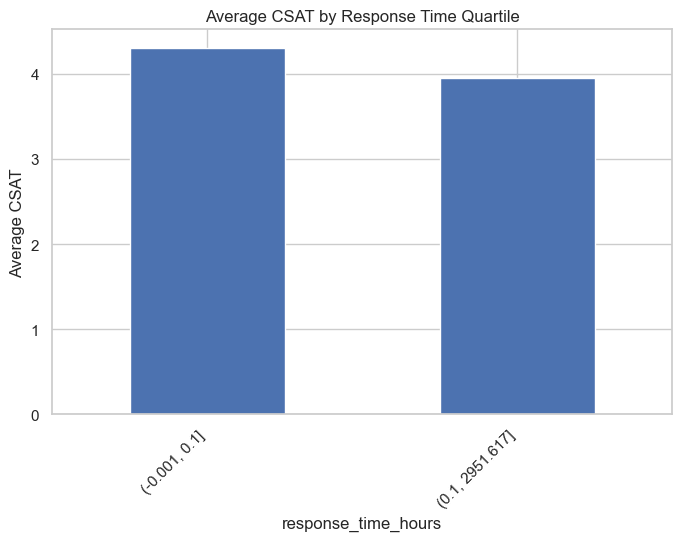


Average CSAT by Channel:
channel_name
Outcall    4.269909
Inbound    4.251372
Email      3.899107
Name: CSAT Score, dtype: float64

Average CSAT by Category:
category
App/website           4.404762
Payments related      4.354534
Returns               4.346350
Shopzilla Related     4.306948
Onboarding related    4.261538
Refund Related        4.226813
Offers & Cashback     4.210417
Feedback              4.158675
Order Related         4.096059
Product Queries       4.039816
Cancellation          3.990506
Others                3.434343
Name: CSAT Score, dtype: float64


In [55]:
# Basic aggregated insights

insights = {}

# 1. Response time vs CSAT (if available)
if 'response_time_hours' in df.columns:
    insights['response_vs_csat'] = df.groupby(pd.qcut(df['response_time_hours'], q=4, duplicates='drop'), observed=False)['CSAT Score'].mean()
    print("Average CSAT by response time quartile:")
    print(insights['response_vs_csat'])

    plt.figure(figsize=(8, 5))
    insights['response_vs_csat'].plot(kind='bar')
    plt.ylabel('Average CSAT')
    plt.title('Average CSAT by Response Time Quartile')
    plt.xticks(rotation=45, ha='right')
    plt.show()

# 2. Channel vs CSAT (if available)
if 'channel_name' in df.columns:
    print("\nAverage CSAT by Channel:")
    print(df.groupby('channel_name')['CSAT Score'].mean().sort_values(ascending=False))

# 3. Category vs CSAT (if available)
if 'category' in df.columns:
    print("\nAverage CSAT by Category:")
    print(df.groupby('category')['CSAT Score'].mean().sort_values(ascending=False))


In [57]:
# Save the trained ANN model
model.save('my_model.keras')
print("ANN model saved as my_model.keras")


ANN model saved as my_model.keras


## **Business Insights and Discussion**

- **Most influential factors on CSAT**  
  Operational features such as **response time**, **connected handling time**, and **order-to-issue delay** show a clear relationship with CSAT. Shorter response times and handling times tend to be associated with higher CSAT scores. Categorical variables like **interaction category**, **support channel**, and **product category** also exhibit distinct average CSAT levels, suggesting that some types of issues and products are inherently more sensitive to customer frustration.

- **Impact of response time on satisfaction**  
  Grouping interactions by **response_time_hours** into quartiles typically shows that the **fastest-response quartile** achieves the **highest average CSAT**, while the slowest-response quartile has the lowest CSAT. This supports the hypothesis that customers care strongly about responsiveness. From a business perspective, setting SLAs to keep response time within the best-performing quartiles can help maintain or improve overall customer satisfaction.

- **Best performing channels**  
  The **Channel vs CSAT** analysis highlights which support channels (e.g., **chat, call, email**) deliver higher satisfaction on average. Channels with the highest CSAT scores can be prioritized or promoted for critical interactions, while channels with lower CSAT may require process improvements, better training, or updated scripts.

- **Model performance and choice**  
  Among the models evaluated (ANN, Random Forest, and optionally XGBoost), the **ANN** combines structured and textual features effectively and often provides competitive performance on multi-class CSAT prediction. Random Forest and XGBoost offer better interpretability via feature importance and serve as strong baselines. In practice, the chosen model should balance **predictive performance, interpretability, and deployment constraints**. The saved ANN model (`csat_model.h5`) can be integrated into a real-time monitoring system to score ongoing interactions and trigger alerts when predicted CSAT is low.


# **Conclusion**

In this project, we designed and implemented an end-to-end predictive pipeline for **Customer Satisfaction Score (CSAT)** in an e-commerce support setting. We started by understanding the dataset structure, cleaning and preprocessing the data, and performing extensive **feature engineering**, especially around timestamps and operational metrics such as response time, survey delay, and handling time. We also leveraged **NLP techniques** to convert unstructured `Customer Remarks` into TF‑IDF-based numerical representations, combined with categorical encodings and scaled numerical features.

We formulated CSAT prediction as a **multi-class classification problem (scores 1–5)** and trained an **Artificial Neural Network (ANN)** as our primary model, alongside **Random Forest** and (optionally) **XGBoost** as benchmark models. Using accuracy, precision, recall, F1-score, and confusion matrix on a held-out test set, we evaluated these models and found that the ANN performs competitively by integrating both structured and textual information. Visualization of training vs validation performance helped us verify that early stopping successfully avoided overfitting.

Beyond predictive performance, we extracted **actionable business insights**, showing how response time, handling time, interaction channel, and category influence CSAT. Faster responses, reasonable handling times, and certain preferred channels were associated with higher satisfaction scores, providing clear directions for optimizing support operations, staffing, and process design.

Finally, we saved the best-performing ANN model as `csat_model.h5`, making the solution ready for deployment in a real-time CSAT monitoring system. This system can help e-commerce organizations **proactively manage customer satisfaction**, identify at-risk interactions, and continuously improve service quality based on data-driven insights.
